```
Load any real-world dataset (Kaggle recommended) into Python.
Apply PCA to reduce features to 2-dimensions.
Apply K-Means clustering on the PCA-reduced data.
If labels exist, map cluster IDs to labels and compute accuracy manually.
Write a function run_pipeline() that:
• loads data
• runs PCA
• runs K-Means
• plots results
• prints metrics
save final plots to a folder using Python code.


First five X_Reduced rows: [[-2.2645417283949008, -0.5057039027737835], [-2.0864255006161585, 0.6554047293691376], [-2.367950449062526, 0.31847731084725023], [-2.304197161152009, 0.5753677125331964], [-2.3887774935056423, -0.6747673967025143]]
48:52 five cluster label [2, 2, 0, 0]
48:52 five mapped label [0, 0, 2, 2]
Cluster Accuracy: 85.33%


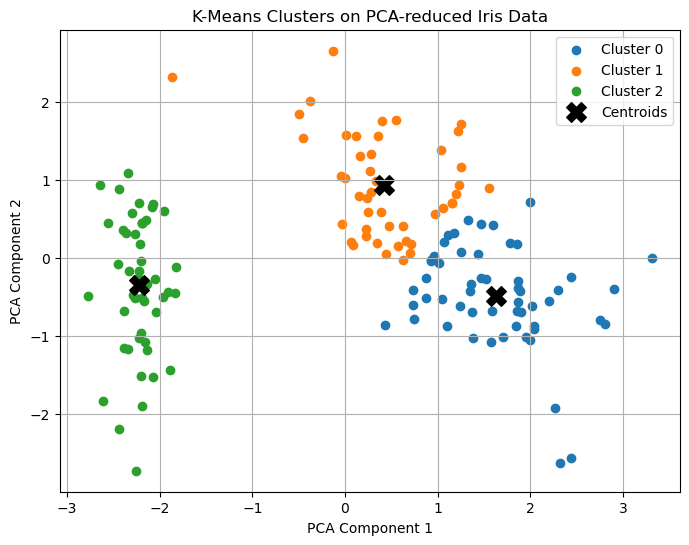

In [84]:
import csv
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import os


# Step 1: Load Iris manually
def load_iris_dataset(filepath):
    X = []
    y = []
    species_to_num = {"setosa":0, "versicolor": 1, "virginica":2 }
    with open(filepath, "r" , newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                sepal_length = float(row["sepal_length"])
                sepal_width = float(row["sepal_width"])
                petal_length = float(row["petal_length"])
                petal_width = float(row["petal_width"])
                species = row["species"]
                X.append([sepal_length,sepal_width,petal_length,petal_width])
                y.append(species_to_num[species])
            except:
                continue
    return X,y


# Step 2: PCA manually
def pca_manual(X, k=2):
    # Standardize manually
    n_features = len(X[0])
    mean = []
    std = []
    for i in range(n_features):
        lst = [row[i] for row in X]
        m = sum(lst)/len(lst)
        s = math.sqrt(sum((x-m)**2 for x in lst)/len(lst))
        mean.append(m)
        std.append(s)

    X_standardized = []
    for row in X:
        scaled_row = [(row[i]-mean[i])/std[i] for i in range(n_features)]
        X_standardized.append(scaled_row)

    # Covariance matrix manually
    n_samples = len(X_standardized)
    cov_matrix = [[0 for _ in range(n_features)] for _ in range(n_features)]
    for i in range(n_features):
        for j in range(n_features):
            cov_ij = sum(X_standardized[s][i]*X_standardized[s][j] for s in range(n_samples))/n_samples
            cov_matrix[i][j] = cov_ij

    cov_matrix_np = np.array(cov_matrix)

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix_np)
    idx = eigenvalues.argsort()[::-1]
    eigenvectors = eigenvectors[:, idx].tolist()

    # Select top-k eigenvectors
    W_k = [row[:k] for row in eigenvectors]

    # Project data manually
    X_reduced = []
    for sample in X_standardized:
        reduced_point = []
        for j in range(k):
            value = sum(sample[i]*W_k[i][j] for i in range(n_features))
            reduced_point.append(value)
        X_reduced.append(reduced_point)

    return X_reduced


# Step 3: K-Means manually
def euclidean_distance(x1,x2):
    return math.sqrt(sum((a-b)**2 for a,b in zip(x1,x2)))

def randomly_initialized(X,K):
    if K<1 or K>len(X):
        raise ValueError("k must be between 1 and number of samples")
    return random.sample(X,K)

def assign_cluster(X,centroids):
    labels = []
    for row in X:
        distance = [euclidean_distance(row,c) for c in centroids]
        labels.append(distance.index(min(distance)))
    return labels

def update_centroids(X, labels, K):
    n_features = len(X[0])
    new_centroids = []
    for k in range(K):
        cluster_points = [X[i] for i in range(len(X)) if labels[i]==k]
        centroid = []
        for f in range(n_features):
            values = [p[f] for p in cluster_points]
            mean_val = sum(values)/len(values) if values else 0
            centroid.append(mean_val)
        new_centroids.append(centroid)
    return new_centroids

def kmeans(X, K, max_iters=100, tol=1e-4):
    centroids = randomly_initialized(X,K)
    for iteration in range(max_iters):
        labels = assign_cluster(X,centroids)
        new_centroids = update_centroids(X,labels,K)
        stable = True
        for c_old, c_new in zip(centroids,new_centroids):
            if euclidean_distance(c_old,c_new) > tol:
                stable = False
                break
        centroids = new_centroids
        if stable:
            break
    return centroids, labels


# Step 4: Map cluster IDs to labels manually & compute accuracy
def map_clusters_to_labels_manual(y_true, cluster_labels, K):
    label_mapping = {}
    
    for cluster in range(K):
        indices = [i for i, c in enumerate(cluster_labels) if c == cluster]
        counts = {}
        for idx in indices:
            label = y_true[idx]
            if label in counts:
                counts[label] += 1
            else:
                counts[label] = 1
        # Find max manually
        max_count = -1
        max_label = None
        for label, count in counts.items():
            if count > max_count:
                max_count = count
                max_label = label
        label_mapping[cluster] = max_label

    mapped_labels = [label_mapping[c] for c in cluster_labels]
    return mapped_labels

def accuracy_manual(y_true, y_pred):
    correct = 0
    for yt, yp in zip(y_true,y_pred):
        if yt == yp:
            correct += 1
    return correct / len(y_true)


# Step 5: Plot clusters and save
def plot_clusters(X_reduced, cluster_labels, centroids, filename="plots/final_plot.png"):
    folder = os.path.dirname(filename)
    if not os.path.exists(folder):
        os.makedirs(folder)

    K = len(centroids)
    plt.figure(figsize=(8,6))
    for i in range(K):
        pts = [X_reduced[j] for j in range(len(X_reduced)) if cluster_labels[j]==i]
        x_pts = [p[0] for p in pts]
        y_pts = [p[1] for p in pts]
        plt.scatter(x_pts, y_pts, label=f"Cluster {i}")
    plt.scatter([c[0] for c in centroids], [c[1] for c in centroids],
                color='black', marker='X', s=200, label='Centroids')
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("K-Means Clusters on PCA-reduced Iris Data")
    plt.legend()
    plt.grid(True)
    plt.savefig(filename)
    plt.show()


# Step 6: Run pipeline
def run_pipeline(filepath):
    # Load
    X, y = load_iris_dataset(filepath)
    
    # PCA
    X_reduced = pca_manual(X, k=2)
    print("First five X_Reduced rows:",X_reduced[:5])
    
    # K-Means
    K = 3
    centroids, cluster_labels = kmeans(X_reduced, K)
    print("48:52 five cluster label",cluster_labels[48:52])
    # Map clusters & accuracy
    mapped_labels = map_clusters_to_labels_manual(y, cluster_labels, K)
    print("48:52 five mapped label",mapped_labels[48:52])

    acc = accuracy_manual(y, mapped_labels)
    print(f"Cluster Accuracy: {acc*100:.2f}%")
    
    # Plot and save
    plot_clusters(X_reduced, cluster_labels, centroids, filename="plots/pca_kmeans_iris.png")


# Run

if __name__=="__main__":
    run_pipeline("iris.csv")
